<h1 style="font-size:40px;"><b>Mmakema Mokoana ST10537616</b></h1>
<h1 style="font-size:40px;"><b>POE Part 1 - Linear Regression  </b></h1>
<h1 style="font-size:40px;"><b>Linear regression - Medical aid cost prediction </b></h1>

AIM : The aim of this project is to develop a predictive model that estimates medical insurance charges based on key demographic and lifestyle factors. Using linear regression, the analysis seeks to identify the most significant variables influencing healthcare costs and evaluate the model’s effectiveness in predicting medical expenses.


Below I have imported all the libraries I will use in the whole project to build the linear regression model and fulful the aim of this project. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor



<h1 style="font-size:20px;"><b>Evaluating the dataset for suitability to apply a linear regressin algorithm </b></h1>

The datasest will be suitable to apply a regression algorithm if the following conditions are met:

1. The target variable is numeric
2. There is a roughly linear relationship between predictors and target
3. Key assumptions are reasonably met

In [2]:
#Reading my dataset
raw_data = pd.read_csv ('insurancea_data.csv')

In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The target variable in this project is charges.  From the info above we can see that the valiable is numeric and continuous with data type 'float' .
The first condition to apply a linear regression is met . 

In [4]:
# A previw of the first 5 rows of the data 
raw_data. head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Defining my variables 

y = raw_data["charges"]

X = raw_data.drop("charges", axis=1)


In [6]:
# Changing the categorical data into booleans for better handling 
#The correlation matrix provides insight into the strength and direction of 
#relationships between the predictor variables and the target variable (charges)
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

#Data after data type concersion
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


In [7]:
#Creating a version 2 dataset so avoid loosing the view of the the original data

raw_data_v2 = X.copy()
raw_data_v2["charges"] = y

In [8]:
raw_data_v2.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charges
0,19,27,0,0,1,0,0,1,16884.92400
1,18,33,1,1,0,0,1,0,1725.55230
2,28,33,3,1,0,0,1,0,4449.46200
3,33,22,0,1,0,1,0,0,21984.47061
4,32,28,0,1,0,1,0,0,3866.85520


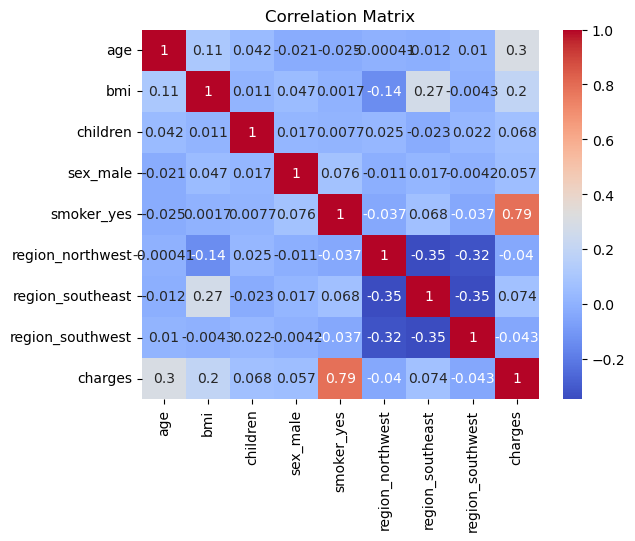

In [9]:
"""
The correlation matrix provides insight into the strength and direction of relationships between the predictor variables and
the target variable. I will use correlation to check if there is any correlation between the predictors and the target variable """


corr = raw_data_v2.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The analysis shows that smoking status has the strongest positive correlation with medical charges (0.79), indicating that smokers tend to incur significantly higher costs.

Age and BMI exhibit moderate positive correlations with charges, suggesting that older individuals and those with higher BMI are likely to experience increased medical expenses. In contrast, variables such as the number of children, gender, and region show very weak or negligible correlations with the target variable.

These results indicate that smoking, age, and BMI are the most influential predictors of medical charges, while the remaining variables contribute minimally to the model.

I will drop number of children, gender, and region in the data, since these predictors have very litle to negligible correlation with the target variable. The remaining data will be the data most beneficial and suitable to the liner regression application. 


<h1 style="font-size:20px;"><b>Exploratory Data Analysis <b></h1>

In [10]:
raw_data_v2.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charges
0,19,27,0,0,1,0,0,1,16884.92400
1,18,33,1,1,0,0,1,0,1725.55230
2,28,33,3,1,0,0,1,0,4449.46200
3,33,22,0,1,0,1,0,0,21984.47061
4,32,28,0,1,0,1,0,0,3866.85520


In [11]:
# Creating Version 3 of the dataset. This is the data without the features that had low corellation to the target variable. 

raw_data_v3 = raw_data_v2.drop(columns=["children", "sex_male", "region_northwest", "region_southeast", "region_southwest"])

raw_data_v3.head()

,age,bmi,smoker_yes,charges
0,19,27,1,16884.92400
1,18,33,0,1725.55230
2,28,33,0,4449.46200
3,33,22,0,21984.47061
4,32,28,0,3866.85520


In [12]:
raw_data_v3.describe()

,age,bmi,smoker_yes,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.169656,0.204783,13270.422265
std,14.049960,6.119875,0.403694,12110.011237
min,18.000000,15.000000,0.000000,1121.873900
25%,27.000000,26.000000,0.000000,4740.287150
50%,39.000000,30.000000,0.000000,9382.033000
75%,51.000000,34.000000,0.000000,16639.912515
max,64.000000,53.000000,1.000000,63770.428010


In [13]:
# Below are plots showing the relatioship between each predictor and the target variable

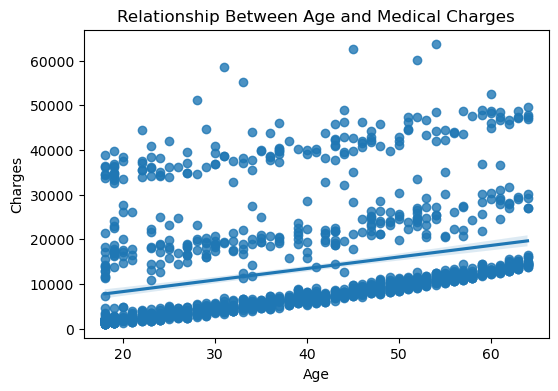

In [14]:
# Age vs Charges
plt.figure(figsize=(6, 4))
sns.regplot(x="age", y="charges", data=raw_data_v3)
plt.title("Relationship Between Age and Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()


The scatter plot shows a positive relationship between age and medical charges, indicating that healthcare costs tend to increase as individuals grow older. While the relationship is not perfectly linear, there is a clear upward trend in the data.

The presence of multiple clusters suggests that additional factors, such as smoking status, may be influencing the variation in charges. Overall, age appears to be a meaningful predictor of medical costs, although it does not fully explain the variability in the target variable.


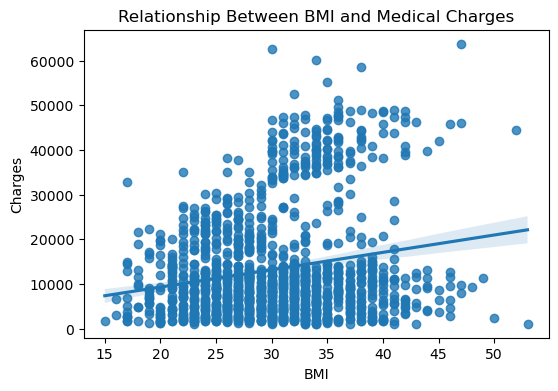

In [15]:
# BMI vs Charges
plt.figure(figsize=(6, 4))
sns.regplot(x="bmi", y="charges", data=raw_data_v3)
plt.title("Relationship Between BMI and Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

The relationship between BMI and medical charges shows a moderate positive trend, where higher BMI values are generally associated with increased healthcare costs. However, the data exhibits significant dispersion, indicating that BMI alone is not a strong predictor of medical charges.

The variability in the data suggests that other variables, such as smoking status, play a more dominant role in influencing medical costs. While BMI contributes to the model, its effect is less pronounced compared to other predictors.


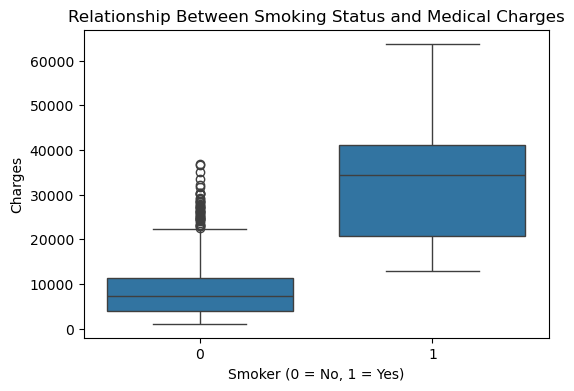

In [16]:
# 3. Smoking Status vs Charges
plt.figure(figsize=(6, 4))
sns.boxplot(x="smoker_yes", y="charges", data=raw_data_v3)
plt.title("Relationship Between Smoking Status and Medical Charges")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Charges")
plt.show()

The boxplot reveals a substantial difference in medical charges between smokers and non-smokers. Individuals who smoke incur significantly higher costs, as indicated by the higher median and wider distribution of charges.

The presence of higher variability among smokers suggests that smoking not only increases medical costs but also contributes to more unpredictable healthcare expenses. This confirms that smoking status is the most influential predictor of medical charges in the dataset.


<h1 style="font-size:20px;"><b>Continued feature selection </b></h1>

In [17]:
X = raw_data_v3.drop("charges", axis=1)
y = raw_data_v3["charges"]

In [18]:
#train baselinefrom sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(model, X, y, scoring="r2", cv=5)
print("Baseline R²:", np.mean(scores))

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

model = LinearRegression()

scores = cross_val_score(model, X, y, scoring="r2", cv=5)
print("Baseline R²:", np.mean(scores))

Baseline R²: 0.7449719618068575
Baseline R²: 0.7449719618068575


In [19]:
#Apply the wrapper method (RFE)

model = LinearRegression()

rfe = RFE(model, n_features_to_select=3)  # you can change this number
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['age', 'bmi', 'smoker_yes'], dtype='object')


In [20]:
# Training Model on the selected features 

X_selected = X[selected_features]

scores_selected = cross_val_score(model, X_selected, y, scoring="r2", cv=5)
print("R² after feature selection:", np.mean(scores_selected))

R² after feature selection: 0.7449719618068575


The R^2 value did not change after using the RFE. This means all the three features (Age, BMI and smoker status) are good features to train the model.  

<h1 style="font-size:20px;"><b> Data quality before model training </b></h1>

In [21]:
raw_data_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   bmi         1338 non-null   int64  
 2   smoker_yes  1338 non-null   int64  
 3   charges     1338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 41.9 KB


The dataset consists of 1,338 observations and contains no missing values, indicating a high level of data completeness. All variables have been converted to numerical data types, making them suitable for quantitative analysis.

Given the absence of null values and the numerical representation of all features, the dataset is well-prepared for the application of a linear regression model.


In [22]:
#Checking for duplicate records

raw_data_v3.duplicated().sum()

np.int64(1)

In [23]:
#There is one duplicated record in the dataset as per the output above. The next step is to inspect the duplicate and drop it. 

raw_data_v3[raw_data_v3.duplicated()]


,age,bmi,smoker_yes,charges
581,19,30,0,1639.5631


In [24]:
#Dropping the duplicate record

raw_data_v3 = raw_data_v3.drop_duplicates()

In [25]:
#Checking if we still have duplicates in the data

raw_data_v3.duplicated().sum()

np.int64(0)

In [26]:
raw_data_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1337 non-null   int64  
 1   bmi         1337 non-null   int64  
 2   smoker_yes  1337 non-null   int64  
 3   charges     1337 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 52.2 KB


After the duplicate record is dropped we see that the dataset has 1337 records. This gives confidence that the record correctly was dropped. 

A duplicate check was performed on the dataset, which revealed the presence of one duplicate record. Duplicate entries can introduce bias and distort model performance, as they may over-represent certain observations. The duplicate record was therefore removed to ensure data integrity and improve the reliability of the analysis.


<h1 style="font-size:20px;"><b>Training the Linear Regression Model with the Version 2 data</b></h1>
This dataset still has all the predictors from the original dataset. This is for comparison purposes to see how the model would have behaved if we kept the predictor variables that showed to have low correlation to the medical aid charges. 
    

In [27]:
raw_data_v2.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charges
0,19,27,0,0,1,0,0,1,16884.92400
1,18,33,1,1,0,0,1,0,1725.55230
2,28,33,3,1,0,0,1,0,4449.46200
3,33,22,0,1,0,1,0,0,21984.47061
4,32,28,0,1,0,1,0,0,3866.85520


In [28]:

A = raw_data_v2[["age", "bmi", "children", "sex_male", "smoker_yes", "region_northwest", "region_southeast", "region_southwest"]]
B = raw_data_v2["charges"]

In [29]:
A_train, A_test, B_train, B_test = train_test_split(
    A, B, test_size=0.2, random_state=42
)

In [30]:
#Training the model

model = LinearRegression()
model.fit(A_train, B_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
#Make Predictions

predictions = model.predict(A_test)

In [32]:

r2 = r2_score(B_test, predictions)
mse = mean_squared_error(B_test, predictions)
rmse = np.sqrt(mse)

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.7837881278275863
RMSE: 5793.670588515428


These model parameters will be used for comparison purposes to see if it is best to train the model with all the features or just with the features that have high corellation to the target variable. 

<h1 style="font-size:20px;"><b>Training the Linear Regression Model with the Version 3 data</b></h1>
This dataset has only 3 predictors (age, BMI, smoker status) that showed to have high corellation to medical aid charges. 

In [33]:
raw_data_v3.head()

,age,bmi,smoker_yes,charges
0,19,27,1,16884.92400
1,18,33,0,1725.55230
2,28,33,0,4449.46200
3,33,22,0,21984.47061
4,32,28,0,3866.85520


In [34]:
#Defining features and targets

X = raw_data_v3[["age", "bmi", "smoker_yes"]]
y = raw_data_v3["charges"]

In [35]:
#Splitting the data into 80% training data and 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was divided into training and testing subsets, with 80% of the data allocated for model training and 20% reserved for evaluation. This approach ensures that the model is assessed on unseen data, providing a more reliable measure of its predictive performance.


In [36]:
#Training the model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
#Make Predictions

predictions = model.predict(X_test)

<h1 style="font-size:20px;"><b>Model Evaluation</b></h1> 

In [38]:
#Evaluating the model

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.8048640132202002
RMSE: 5988.10661924385


The model achieved an R-squared value of 0.805, indicating that approximately 80.5% of the variability in medical insurance charges is explained by the predictor variables. This suggests that the model has strong explanatory power and is able to capture the key relationships within the data.

The root mean squared error (RMSE) was calculated to be approximately 5,988, which indicates that the model’s predictions deviate from the actual values by this amount on average. While this level of error is moderate, it is acceptable given the variability and complexity of healthcare costs.

Overall, the results demonstrate that the linear regression model performs well as a baseline predictive model, although some prediction error remains, particularly for higher-cost observations.


<h1 style="font-size:20px;"><b>Comparing this model with the model trained with v2 data above.</b></h1> 

A comparison of the two models indicates that the second model performs better overall. Although it has a slightly higher root mean squared error (RMSE), its R-squared value is higher, suggesting that it explains a greater proportion of the variability in medical charges.

The increase in RMSE is relatively small and acceptable given the improvement in explanatory power. Therefore, the second model is preferred, as it provides a better balance between capturing underlying patterns in the data and maintaining reasonable predictive accuracy.


<h1 style="font-size:20px;"><b>Interpreting the model trained with V3 data.</b></h1> 
This is the model chosen as the final model for this project as it performs better than the model trained with all the features from the raw data set. 

In [40]:
print(model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

-10584.797997984388


,Feature,Coefficient
0,age,252.098953
1,bmi,303.261078
2,smoker_yes,23082.639975


The intercept of the model is estimated at -10,584.80 and represents the predicted medical charges when all predictor variables are equal to zero. While this value is mathematically necessary for the regression equation, it does not have practical significance, as zero values for variables such as age and BMI are not realistic in this context.

The coefficient for age (252.10) indicates that medical charges increase by approximately 252 units for each additional year of age, holding all other variables constant. This suggests a positive relationship between age and healthcare costs.

Similarly, the coefficient for BMI (303.26) shows that an increase in body mass index is associated with higher medical charges, with each unit increase in BMI contributing approximately 303 units to the predicted cost. This reflects the impact of body weight on health-related expenses.

The coefficient for smoking status (23,082.64) is significantly larger than the other predictors, indicating that smoking is the most influential factor in the model. Individuals who smoke are predicted to incur substantially higher medical charges compared to non-smokers, highlighting the strong effect of lifestyle-related risk factors on healthcare costs.

Overall, the model suggests that smoking status is the dominant predictor of medical charges, while age and BMI contribute positively but to a lesser extent.


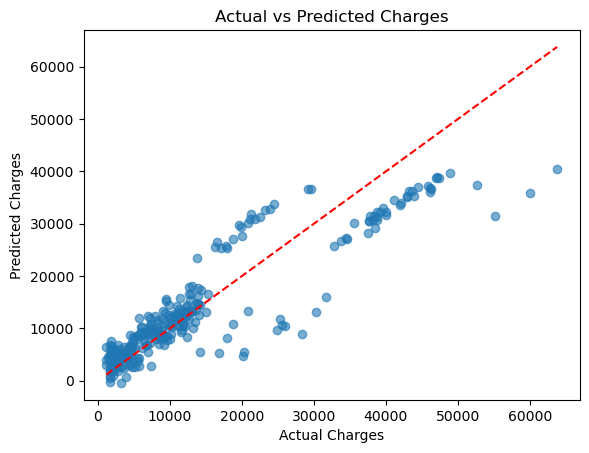

In [41]:
#Visual Evaluation 

plt.scatter(y_test, predictions, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

<h1 style="font-size:20px;"><b>Reflection</b></h1>

The analysis demonstrates that smoking status is the most influential factor affecting medical insurance charges, as smokers consistently incur significantly higher costs. This can be attributed to the increased health risks associated with smoking, which often lead to higher medical expenses.

While the linear regression model performed well, there are opportunities for improvement. The inclusion of additional variables, such as medical history or lifestyle factors, could enhance predictive accuracy. Furthermore, exploring more advanced models may help capture non-linear relationships present in the data.

This project highlights the importance of data preparation, exploratory analysis, and model evaluation in building reliable predictive models.
